In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

print("GPU доступен:", tf.config.list_physical_devices('GPU'))

GPU доступен: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Train: (50000, 32, 32, 3) (50000, 1)
Test: (10000, 32, 32, 3) (10000, 1)


In [ ]:
class_names = ["airplane","automobile","bird","cat","deer", "dog","frog","horse","ship","truck"]

In [ ]:
def build_model_A():
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(32,32,3)))
    model.add(layers.Conv2D(32, (3,3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3,3), padding="same", activation="relu"))
    model.add(layers.Conv2D(64, (3,3), activation="relu"))
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
model_A = build_model_A()

history_A = model_A.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4371 - loss: 1.5365 - val_accuracy: 0.5792 - val_loss: 1.1907
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6189 - loss: 1.0773 - val_accuracy: 0.6589 - val_loss: 0.9783
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6913 - loss: 0.8816 - val_accuracy: 0.7112 - val_loss: 0.8405
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7305 - loss: 0.7695 - val_accuracy: 0.7267 - val_loss: 0.7800
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7609 - loss: 0.6792 - val_accuracy: 0.7426 - val_loss: 0.7570
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7908 - loss: 0.6014 - val_accuracy: 0.7476 - val_loss: 0.7424
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8117 - loss: 0.5364 - val_accuracy: 0.7512 - val_loss: 0.7365
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8287 - loss: 0.4793 - val_accuracy: 

In [ ]:
def build_model_B():
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3,3), padding="same", input_shape=(32,32,3)))
    model.add(layers.LeakyReLU())
    model.add(layers.Conv2D(32, (3,3), padding="same"))
    model.add(layers.LeakyReLU())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.4))

    model.add(layers.Conv2D(64, (3,3), padding="same"))
    model.add(layers.LeakyReLU())
    model.add(layers.Conv2D(64, (3,3)))
    model.add(layers.LeakyReLU())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(128))
    model.add(layers.LeakyReLU())
    model.add(layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
model_B = build_model_B()

history_B = model_B.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.4951 - loss: 1.4076 - val_accuracy: 0.6420 - val_loss: 1.0246
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6611 - loss: 0.9724 - val_accuracy: 0.6806 - val_loss: 0.9217
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7150 - loss: 0.8172 - val_accuracy: 0.7249 - val_loss: 0.7836
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7467 - loss: 0.7266 - val_accuracy: 0.7329 - val_loss: 0.7739
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7721 - loss: 0.6511 - val_accuracy: 0.7295 - val_loss: 0.8144
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7916 - loss: 0.5905 - val_accuracy: 0.7486 - val_loss: 0.7593
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8128 - loss: 0.5324 - val_accuracy: 0.7484 - val_loss: 0.7608
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8273 - loss: 0.4918 - val_accuracy: 

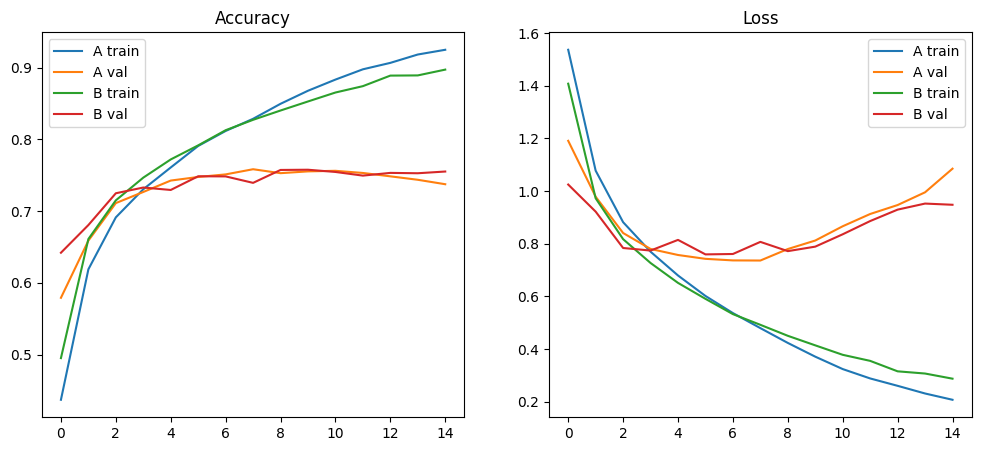

In [ ]:
plt.figure(figsize=(12,5))

# accuracy
plt.subplot(1,2,1)
plt.plot(history_A.history["accuracy"], label="A train")
plt.plot(history_A.history["val_accuracy"], label="A val")
plt.plot(history_B.history["accuracy"], label="B train")
plt.plot(history_B.history["val_accuracy"], label="B val")
plt.title("Accuracy")
plt.legend()

# loss
plt.subplot(1,2,2)
plt.plot(history_A.history["loss"], label="A train")
plt.plot(history_A.history["val_loss"], label="A val")
plt.plot(history_B.history["loss"], label="B train")
plt.plot(history_B.history["val_loss"], label="B val")
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
test_loss_A, test_acc_A = model_A.evaluate(x_test, y_test, verbose=0)
test_loss_B, test_acc_B = model_B.evaluate(x_test, y_test, verbose=0)

print("Model A accuracy:", test_acc_A)
print("Model B accuracy:", test_acc_B)

Model A accuracy: 0.7293999791145325
Model B accuracy: 0.7476999759674072
